In [1]:
import json
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wilcoxon
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [5]:
base_folders = [
    "../output/multi-mission/atstart-income/logs",
    "../output/multi-mission/online-income/logs",
]

fname_re = re.compile(
    r"^test-multi_(?P<robot_count>\d+)_(?P<mission_size>\d+)_t_cleaning_(?P<inventory_id>i\d+)_(?P<mode>[^_]+)$"
)

line_re = re.compile(
    r"(Fragments assigned|No fragments assigned)\.\s*Time:\s*(?P<time>[\d\.]+)\s*milliseconds",
    re.IGNORECASE,
)

rows = []
for folder_path in base_folders:
    arrival = "atstart" if "atstart-income" in str(folder_path) else "online"

    folder = Path(folder_path)
    if not folder.exists():
        print(f"Folder {folder_path} does not exist!")
        continue
    for f in folder.glob("*.log"):
        test_id = f.stem
        m = fname_re.match(test_id)
        if not m:
            continue
        robot_count = int(m.group("robot_count"))
        mission_size = int(m.group("mission_size"))
        inventory_id = m.group("inventory_id")
        mode = m.group("mode")

        with f.open("r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                lm = line_re.search(line)
                if lm:
                    assigned_text = lm.group(1)
                    assigned = True if "Fragments assigned" in assigned_text else False
                    assignment_time = float(lm.group("time"))
                    rows.append({
                        "test_id": test_id,
                        "arrival": arrival,
                        "mode": mode,
                        "robot_count": robot_count,
                        "mission_size": mission_size,
                        "inventory_id": inventory_id,
                        "assigned": assigned,
                        "assignment_time": assignment_time,
                    })

assignment_times_df = pd.DataFrame(rows, columns=[
    "test_id", "arrival", "mode", "robot_count", "mission_size",
    "inventory_id", "assigned", "assignment_time"
])

assignment_times_df

,test_id,arrival,mode,robot_count,mission_size,inventory_id,assigned,assignment_time
0,test-multi_5_20_t_cleaning_i0_bl2,atstart,bl2,5,20,i0,True,3.510
1,test-multi_5_20_t_cleaning_i0_bl2,atstart,bl2,5,20,i0,False,3.687
2,test-multi_5_20_t_cleaning_i0_bl2,atstart,bl2,5,20,i0,False,1.250
3,test-multi_5_20_t_cleaning_i0_bl2,atstart,bl2,5,20,i0,False,2.038
4,test-multi_5_20_t_cleaning_i0_bl2,atstart,bl2,5,20,i0,False,1.566
...,...,...,...,...,...,...,...,...
61650,test-multi_2_20_t_cleaning_i1_multi3,online,multi3,2,20,i1,False,2.328
61651,test-multi_2_20_t_cleaning_i1_multi3,online,multi3,2,20,i1,False,4.538
61652,test-multi_2_20_t_cleaning_i1_multi3,online,multi3,2,20,i1,False,2.813
61653,test-multi_2_20_t_cleaning_i1_multi3,online,multi3,2,20,i1,False,0.831


In [6]:
assigment_times_multi3 = assignment_times_df[assignment_times_df["mode"] == "multi3"]
assigment_times_multi3

,test_id,arrival,mode,robot_count,mission_size,inventory_id,assigned,assignment_time
667,test-multi_10_20_t_cleaning_i0_multi3,atstart,multi3,10,20,i0,True,39.319
668,test-multi_10_20_t_cleaning_i0_multi3,atstart,multi3,10,20,i0,False,1.811
669,test-multi_10_20_t_cleaning_i0_multi3,atstart,multi3,10,20,i0,False,3.160
670,test-multi_10_20_t_cleaning_i0_multi3,atstart,multi3,10,20,i0,False,1.079
671,test-multi_10_20_t_cleaning_i0_multi3,atstart,multi3,10,20,i0,False,3.492
...,...,...,...,...,...,...,...,...
61650,test-multi_2_20_t_cleaning_i1_multi3,online,multi3,2,20,i1,False,2.328
61651,test-multi_2_20_t_cleaning_i1_multi3,online,multi3,2,20,i1,False,4.538
61652,test-multi_2_20_t_cleaning_i1_multi3,online,multi3,2,20,i1,False,2.813
61653,test-multi_2_20_t_cleaning_i1_multi3,online,multi3,2,20,i1,False,0.831


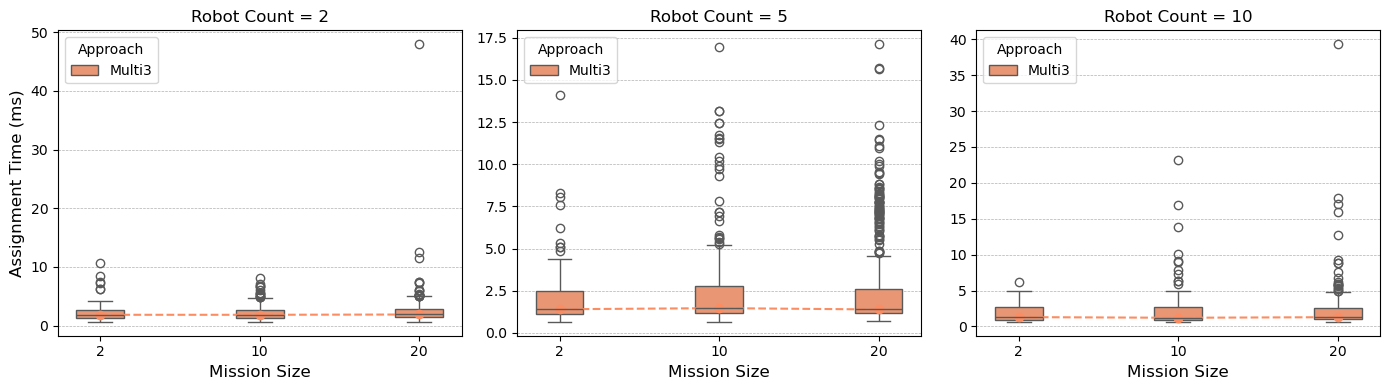

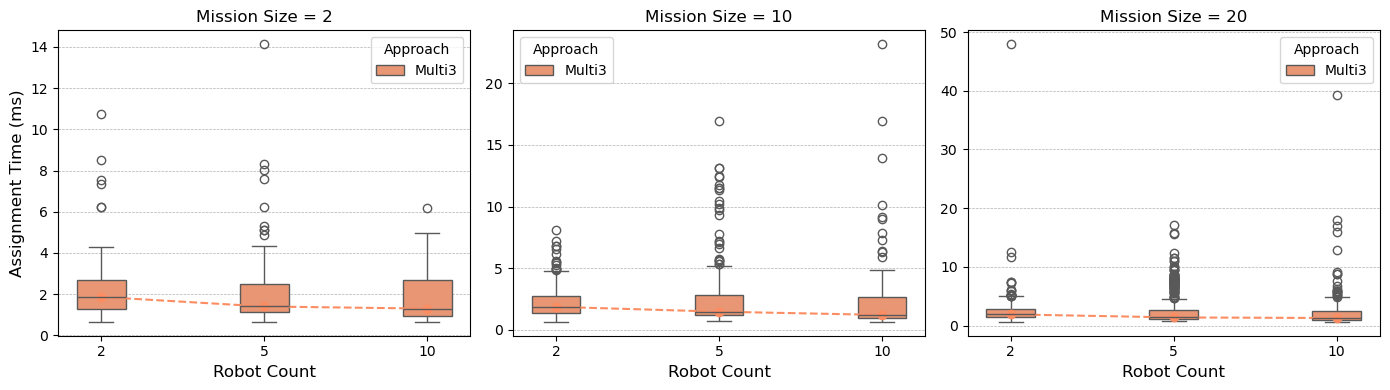

In [8]:
palette = sns.color_palette("Set2")
approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

def multi_box_plot(df,output_file_name, external_variable, var_x, var_y, external_variable_label, x_label, y_label):
    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(14, 4))

    for i, external_variable_value in enumerate(external_variable_values):
        ax = axes[i]
        xx_df = df[df[external_variable] == external_variable_value][[var_x, var_y, "mode"]].copy()
        xx_df["Approach"] = xx_df["mode"].apply(lambda x: "Baseline" if x in {"bl0", "bl1", "bl2"} else "Multi3")

        sns.boxplot(data=xx_df, x=var_x, y=var_y, hue="Approach", palette=approach_colors, width=0.3, ax=ax)

        mission_sizes = sorted(xx_df[var_x].unique())
        x_ticks = range(len(mission_sizes))

        for approach, color in approach_colors.items():
            medians = []
            for size in mission_sizes:
                values = xx_df[(xx_df[var_x] == size) & (xx_df["Approach"] == approach)][var_y]
                if not values.empty:
                    medians.append(np.median(values))
                else:
                    medians.append(np.nan)

            ax.plot(x_ticks, medians, marker="o", linestyle="--", color=color)

        ax.set_title(f"{external_variable_label} = {external_variable_value}")
        ax.set_xlabel(x_label, fontsize=12)
        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")
        ax.yaxis.grid(True, linestyle="--", linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_file_name, format="pdf")
    plt.show()

multi_box_plot(assigment_times_multi3, "../output/single-mission/images/assignment_times_by_mission_size_box.pdf", "robot_count", "mission_size", "assignment_time", "Robot Count", "Mission Size", "Assignment Time (ms)")
multi_box_plot(assigment_times_multi3, "../output/single-mission/images/assignment_times_by_robot_count_box.pdf", "mission_size", "robot_count", "assignment_time", "Mission Size", "Robot Count", "Assignment Time (ms)")

In [9]:
assignment_stats_multi3 = assigment_times_multi3.groupby(
    ['robot_count', 'mission_size', 'assigned']
)['assignment_time'].agg(
    mean='mean',
    median='median',
    q1=lambda x: np.percentile(x, 25),
    q3=lambda x: np.percentile(x, 75),
    p90=lambda x: np.percentile(x, 90),
    p99=lambda x: np.percentile(x, 99)
).reset_index()

assignment_stats_multi3

,robot_count,mission_size,assigned,mean,median,q1,q3,p90,p99
0,2,2,False,2.064189,1.8380,1.24000,2.67000,3.1856,6.98956
1,2,2,True,2.116789,1.9990,1.34600,2.89375,3.4548,3.77122
2,2,10,False,2.086252,1.8690,1.31300,2.79100,3.2572,4.88772
3,2,10,True,1.894099,1.8250,1.51275,2.15375,2.6087,4.54435
4,2,20,False,2.178904,1.9595,1.41175,2.90925,3.3330,4.96035
5,2,20,True,1.856109,1.8080,1.38625,2.11875,2.6823,4.44709
6,5,2,False,1.821833,1.3650,1.10450,2.47300,3.2236,5.04206
7,5,2,True,2.683735,1.6325,1.36050,2.59800,5.8780,12.20711
8,5,10,False,1.975263,1.3900,1.14350,2.43050,3.3085,10.82440
9,5,10,True,2.819290,2.3770,1.39900,3.31425,4.2929,12.87045


In [10]:
assignment_stats_multi3_overall_assignment = assigment_times_multi3.groupby(
    ['assigned']
)['assignment_time'].agg(
    mean='mean',
    median='median',
    q1=lambda x: np.percentile(x, 25),
    q3=lambda x: np.percentile(x, 75),
    p90=lambda x: np.percentile(x, 90),
    p99=lambda x: np.percentile(x, 99)
).reset_index()

assignment_stats_multi3_overall_assignment

,assigned,mean,median,q1,q3,p90,p99
0,False,2.035047,1.685,1.16500,2.7500,3.2814,7.30784
1,True,2.240229,1.797,1.28175,2.7365,3.5084,10.26907


In [16]:
assignment_stats_multi3_overall_assignment = assigment_times_multi3['assignment_time'].agg(
    mean='mean',
    median='median',
    q1=lambda x: np.percentile(x, 25),
    q3=lambda x: np.percentile(x, 75),
    p90=lambda x: np.percentile(x, 90),
    p99=lambda x: np.percentile(x, 99)
).reset_index()

assignment_stats_multi3_overall_assignment 

/var/folders/fw/n2pm2wss0g3294k9bwthxd6h0000gn/T/ipykernel_26522/609296451.py:1: FutureWarning: using <function <lambda> at 0x12f16e3a0> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  assignment_stats_multi3_overall_assignment = assigment_times_multi3['assignment_time'].agg(
/var/folders/fw/n2pm2wss0g3294k9bwthxd6h0000gn/T/ipykernel_26522/609296451.py:1: FutureWarning: using <function <lambda> at 0x12f16e430> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  assignment_stats_multi3_overall_assignment = assigment_times_multi3['assignment_time'].agg(
/var/folders/fw/n2pm2wss0g3294k9bwthxd6h0000gn/T/ipykernel_26522/609296451.py:1: FutureWarning: using <function <lambda> at 0x12f16ea60> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  assignment_stats_multi3_overall_assignment = assigment_times_multi3['assignment_time

ValueError: cannot perform both aggregation and transformation operations simultaneously